<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Exploring the MUSE View of NGC 253**

This notebook demonstrates how to access and explore [MUSE](https://www.eso.org/sci/facilities/develop/instruments/muse.html) observations of the nearby starburst galaxy NGC 253, released as part of the **first public data release of The MUSE View of the Sculptor** programme. The primary data product is a **364 GB (339 GiB)** MUSE mosaic data cube — the largest optical integral field dataset ever released for a nearby galaxy. Rather than downloading the full cube, this notebook shows how to programmatically request **cutouts** — small, spatially and/or spectrally cropped subsets of the full dataset — via ESO’s [Science Archive Facility](https://archive.eso.org/cms.html).

---

### 🗂️ **Data Products**

This release consists of a [Phase 3 validated science product](https://www.eso.org/sci/observing/phase3.html), part of the [108.2289](https://archive.eso.org/scienceportal/home?data_collection=108.2289) data collection (DOI: [10.18727/archive/100](https://doi.org/10.18727/archive/100)). It is a **community-delivered, ESO-ingested dataset** available via the Science Archive Facility:

- 📦 [ADP.2025-07-06T07:52:11.871](https://archive.eso.org/dataset/ADP.2025-07-06T07:52:11.871): full-resolution MUSE mosaic data cube preview
- 📊 [Ancillary DAP maps (~10 GB)](https://dataportal.eso.org/dataPortal/file/ADP.2025-07-06T07:52:11.876): emission-line fluxes (e.g. Hα, [N II], [S II]), stellar and gas kinematics, moment maps  
- 📝 [Official data release description](https://www.eso.org/rm/api/v1/public/releaseDescriptions/236): documentation for the Phase 3 collection
- 📰 [ESO press release (eso2510)](https://www.eso.org/public/news/eso2510/): media highlights from ESO  

---

### 🌀 **Dataset Overview**

The mosaic was built from **103 individual MUSE pointings** in Wide Field Mode (WFM) with extended wavelength coverage. Most pointings (**101**) were taken without adaptive optics (AO), with approx **850 s** exposure times. Two central pointings covering the nuclear region used AO and longer integrations (**≈2000 s**), providing higher spatial resolution across the starburst core. The final mosaic spans approximately **20′ × 5′**, and provides a richly detailed view of the ionised gas, stellar populations, and dust in this prototypical Sculptor group galaxy.

<p align="center">
  <img src="https://cdn.eso.org/images/screen/eso2510a.jpg" alt="MUSE View of NGC 253" width="1000"/>
  <img src="https://cdn.eso.org/images/screen/eso2510b.jpg" alt="MUSE View of NGC 253" width="1000"/>
  <br>
  <em>Figure: MUSE mosaic of the Sculptor galaxy NGC 253, showing stellar continuum and ionised gas (Credit: ESO/E. Congiu et al.).</em>
</p>

---

### ✂️ **What’s a Cutout?**

Given the large file size, downloading the full cube is often impractical. Instead, this notebook shows how to retrieve **cutouts**: smaller FITS cubes extracted from the mosaic, selected by:

- **Spatial** coordinates (RA, Dec)  
- **Spectral** range (wavelength)  
- Or both  

Cutouts allow efficient exploration of targeted regions or specific emission lines without transferring the full dataset.

---

### 💻 **How to Use This Notebook**

You can view this notebook as a static HTML page or run it interactively via [Jupyter](https://jupyter.org/install). It’s also available, alongside other examples, on the ESO [programmatic access page](https://archive.eso.org/programmatic/#SCRIPT).

To interact with the notebook:

- Navigate cells with the arrow keys  
- Execute a cell with `Ctrl+Enter` or `Cmd+Enter` (on Mac)  
- Modify and re-run code to explore custom regions or lines

---

### 🧪 Tested Environment

This notebook was last tested with:

- Python **3.13.5**
- numpy, matplotlib, astropy for the notebook workflow
- requests and optional tqdm for the local SODA download helper

While other recent Python 3 versions should work, using the tested environment ensures compatibility.

---

### ⚠️ **Known Issue with Large Requests**

> **Note:** If you receive a timeout error when making a cutout request, this is expected behavior given the size of the dataset. Depending on server load, multiple attempts may be required before the request succeeds. We are actively investigating ways to improve responsiveness for exceptionally large data products like this one.

### **Compatibility Note**

This notebook uses a helper module (`helpers/muse_cutout.py`) for SODA cutout downloads and FITS wavelength-axis extraction. Ensure this file is available in the local `helpers/` directory next to the notebook.

<hr style="border:2px solid #0281c9"> </hr>

## **Importing the necessary modules**

In [ ]:
# Use postponed evaluation of type hints (PEP 563).
# This means annotations are stored as strings and not evaluated at runtime,
# making forward references and imports cleaner. Enabled by default in Python >=3.11.
from __future__ import annotations

# --- Standard library ---
import sys

# --- Third-party scientific libraries ---
import numpy as np
from matplotlib import pyplot as plt

# --- Astropy (astronomy-specific) ---
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

# Print key package and python versions
print("Environment Information:\n")
print(f"{'Python':<12} {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")
for pkg in ["numpy", "matplotlib", "astropy"]:
    try:
        mod = __import__(pkg)
        print(f"{pkg:<12} {mod.__version__}")
    except ImportError:
        print(f"{pkg:<12} not installed")

Environment Information:

Python       3.12.12
numpy        2.4.6
matplotlib   3.10.8
astropy      7.2.0


## **Import local helper functions**

The SODA cutout download and FITS wavelength-axis utilities used in this notebook are imported from `helpers/muse_cutout.py`. Keeping these reusable functions outside the notebook makes the example easier to read while preserving the same calls used below: `get_cutout(...)` for ESO Data Portal cutouts and `get_wavelengthaxis(...)` for extracting the spectral axis from the returned FITS cube.

In [ ]:
# --- Local helpers ---
from helpers.muse_cutout import get_cutout, get_wavelengthaxis

## **Retrieve the NGC 253 dataset**

### **Get Halpha Spectrum and Map towards centre of NGC253**
First, we download a small part of the NGC 253 dataset toward the centre of the galaxy and inspect the Halpha emission both spectrally and spatially. We start by resolving the target coordinates and defining the cutout region.

In [2]:
target = "NGC253" # The target galaxy NGC 253
dp_id = "ADP.2025-07-06T07:52:11.871" # Data product ID for the NGC 253 dataset

In [3]:
coords = SkyCoord.from_name(target) # Convert target name to coordinates
ra = coords.ra.deg # Right Ascension in degrees
dec = coords.dec.deg # Declination in degrees
radius = (60*u.arcsec).to("deg").value # Radius in degrees

wave_min = 652e-9  # Minimum wavelength in meters
wave_max = 662e-9  # Maximum wavelength in meters

#### **Get cutout from the ESO Data Portal** 
Now we use `get_cutout` to retrieve a **60 arcsec** cutout around the central position and the **Halpha + [N II]** wavelength range defined above.  

By default the file is saved as **`[dp_id].fits`**, but you can specify a custom name via `outfile=...`.

In [4]:
# Get the cutout from the ESO Data Portal
outdir = "./data/"
outfile = "cutout1.fits"
outfile = get_cutout(dp_id, ra, dec, radius, 
                      wave_min=wave_min, wave_max=wave_max, 
                      outdir=outdir, outfile=outfile, 
                      verbose=True, overwrite=True)

# Open the cutout FITS file and return the HDU list
hdul = fits.open(outfile)

Requesting cutout from URL: https://dataportal.eso.org/dataPortal/soda/sync?ID=ADP.2025-07-06T07:52:11.871&CIRCLE=11.8880583+-25.2888+0.016667&BAND=6.52e-07+6.62e-07
Estimated download size: 262.5 MB


Downloading: 100%|██████████| 263M/263M [00:29<00:00, 8.98MB/s] 

Wrote: data/cutout1.fits


> **Note:** Timeout errors are normal when requesting data from such a large dataset. If this happens, simply try again — depending on server load, several attempts may be needed before the request succeeds.

#### **Extract downloaded data**

The downloaded cutout is a MUSE cube. We use the imported `get_wavelengthaxis` helper to read the spectral axis from the FITS WCS keywords, then collapse the cube into a continuum estimate, an Halpha + [N II] line map, and an average continuum-subtracted spectrum.

In [5]:
data = hdul[1].data # Get image data from the second HDU
data_wave = get_wavelengthaxis(hdul) # Get the wavelength axes from the FITS file
data_cont = np.nanmedian(data, axis=0) # Median over the spectral dimension to get the (approximate) continuum map
data_line = np.nansum(data - data_cont, axis=0)  # Subtract the continuum to get the line map and sum over the spectral dimension
data_spec = np.nanmean(data - data_cont, axis=(1,2))  # Subtract the continuum to get the line map and average over the spatial dimensions

#### **Plot downloaded data (spectrum)** 
Plot the continuum-subtracted spectrum around the Halpha emission line, averaged over the spatial dimensions.

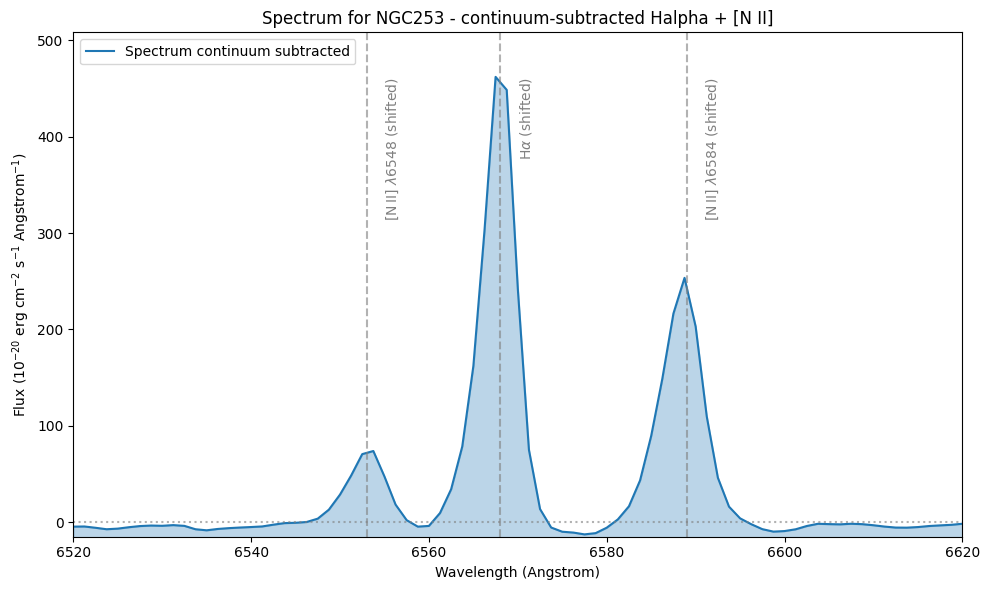

In [6]:
# Define key emission lines in Angstrom
lines = {
    r'[N II] $\lambda6548$': 6548,
    r'H$\alpha$': 6563,
    r'[N II] $\lambda6584$': 6584,
}

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(data_wave, data_spec, label='Spectrum continuum subtracted')
ax.fill_between(data_wave, -20, data_spec, where=(data_spec > -20), alpha=0.3, color='C0')
ax.hlines(0, data_wave[0], data_wave[-1], color='gray', linestyle=':', alpha=0.6)

# Add vertical lines and labels for key lines
for label, wave in lines.items():
    if ax.get_xlim()[0] < wave < ax.get_xlim()[1]:  # Only show if within plotting range
        ax.axvline(wave+5, color='gray', linestyle='--', alpha=0.6)
        ax.text(wave + 7, np.nanmax(data_spec), 
                label+' (shifted)', 
                rotation=90, verticalalignment='top', fontsize=10, color='gray')
        # Note here we shift the lines to match the systemic velocity of the region

ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel(r'Flux (10$^{-20}$ erg cm$^{-2}$ s$^{-1}$ Angstrom$^{-1}$)')
ax.set_title(f'Spectrum for {target} - continuum-subtracted Halpha + [N II]')

ax.set_ylim(-15, np.nanmax(data_spec) * 1.1)  # Set y-limits to avoid clipping
ax.set_xlim(6520, 6620)

ax.legend()
fig.tight_layout()
fig.savefig("./figures/muse_ngc253_spectrum_halpha.png", dpi=300, bbox_inches='tight')

#### **Plot downloaded data (map)** 

Plot the Halpha + [N II] emission and continuum maps, computed as the spectral sum and median, respectively.

We also mark the position of interest on both maps (at pixel = `[145, 250]`) - for which we will extract the full spectrum in the next step (note, aperture not to scale).

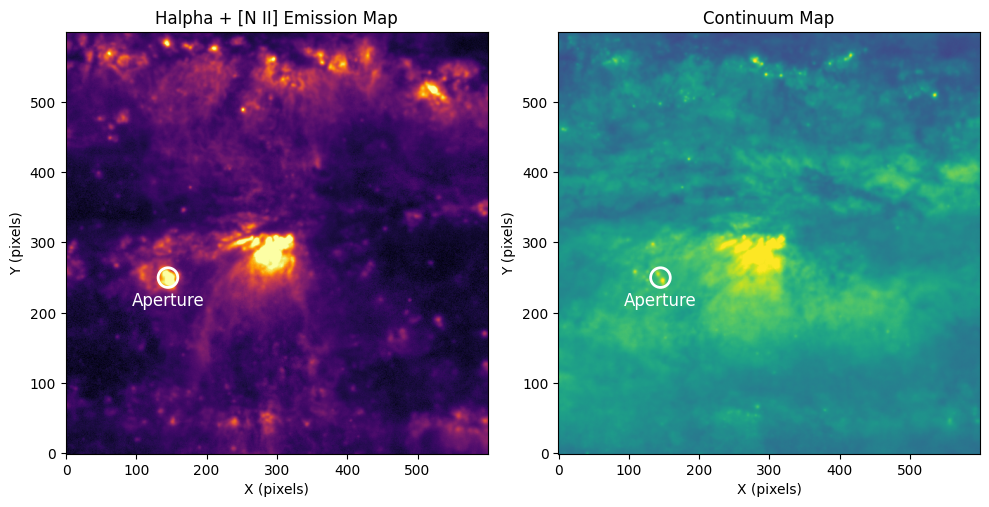

In [7]:
pos = [145, 250]

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

map1 = np.sqrt(np.abs(data_line)) # included abs here to avoid error on sqrt of negative values
map2 = np.sqrt(np.abs(data_cont))

cmap1 = plt.cm.inferno
cmap2 = plt.cm.viridis
cmap1.set_bad(color=cmap1(0))
cmap2.set_bad(color=cmap2(0))

ax1.imshow(map1, origin='lower', cmap=cmap1, vmin=np.nanpercentile(map1, 0), vmax=np.nanpercentile(map1, 99.5))
ax2.imshow(map2, origin='lower', cmap=cmap2, vmin=0, vmax=np.nanpercentile(map2, 99.5))

ax1.scatter(pos[0], pos[1], color='white', marker='o', s=200, lw=2, fc='none')
ax2.scatter(pos[0], pos[1], color='white', marker='o', s=200, lw=2, fc='none')

ax1.text(pos[0], pos[1] - 20, 'Aperture', color='white', fontsize=12, ha='center', va='top')
ax2.text(pos[0], pos[1] - 20, 'Aperture', color='white', fontsize=12, ha='center', va='top')

ax1.set_title('Halpha + [N II] Emission Map')
ax2.set_title('Continuum Map')
ax1.set_xlabel('X (pixels)')
ax2.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax2.set_ylabel('Y (pixels)')

fig.tight_layout()
fig.savefig("./figures/muse_ngc253_maps_halpha.png", dpi=300, bbox_inches='tight')

### **Get the full spectrum at the position of interest (e.g. H II region)**
Now we can extract the full spectrum at the position of interest, corresponding to a compact H II region in NGC 253.

First, we convert the aperture position marked above from pixel coordinates into sky coordinates, which are then used for the spectral cutout request.

In [8]:
wcs = WCS(hdul[1].header)
coords = wcs.pixel_to_world(pos[0], pos[1], 0)[0]
print(f"Position in sky coordinates: {coords.to_string('decimal')} degrees")
print(f"Position in sky coordinates: {coords.to_string('hmsdms')}")
print(f"Position in pixel coordinates: {pos[0]}, {pos[1]}")

ra = coords.ra.deg # Right Ascension in degrees
dec = coords.dec.deg # Declination in degrees
radius = (1*u.arcsec).to("deg").value # Radius in degrees

Position in sky coordinates: 11.8974 -25.2855 degrees
Position in sky coordinates: 00h47m35.37532805s -25d17m07.84008262s
Position in pixel coordinates: 145, 250


Then, as before, we use `get_cutout` to retrieve the full spectrum at that position. Here we omit `wave_min` and `wave_max`, so the returned cutout spans the full spectral range. We request a small 1 arcsec radius aperture, approximately one point-spread function for these data, and average over the spatial dimensions to obtain the spectrum.

In [10]:
# Get the cutout from the ESO Data Portal
# Given no constraints on wavelength, we get the full cutout
outdir = "./data/"
outfile = "cutout2.fits"
outfile = get_cutout(dp_id, ra, dec, radius, 
                      outdir=outdir, outfile=outfile, 
                      verbose=True, overwrite=True)

# Open the cutout FITS file and return the HDU list
hdul = fits.open(outfile)

Requesting cutout from URL: https://dataportal.eso.org/dataPortal/soda/sync?ID=ADP.2025-07-06T07:52:11.871&CIRCLE=11.897397200217583+-25.2855111340605+0.000278
Estimated download size: 3.5 MB


Downloading: 100%|██████████| 3.53M/3.53M [00:00<00:00, 8.49MB/s]

Wrote: data/cutout2.fits


> **Note:** If you receive a timeout error when making the above call, this is normal for such a large dataset. Please try again — depending on server traffic, it can take several retries before succeeding.

As before, we extract the spectrum from the downloaded cube.

In [11]:
data = hdul[1].data # Get image data from the second HDU
data_wave = get_wavelengthaxis(hdul) # Get the wavelength axes from the FITS file
masked_data = np.ma.masked_invalid(data) # mask invalid values in the data (possible that some channels have all NaN values)
data_spec = masked_data.mean(axis=(1, 2)).filled(np.nan)

Finally, we plot the full spectrum and label several prominent emission lines.

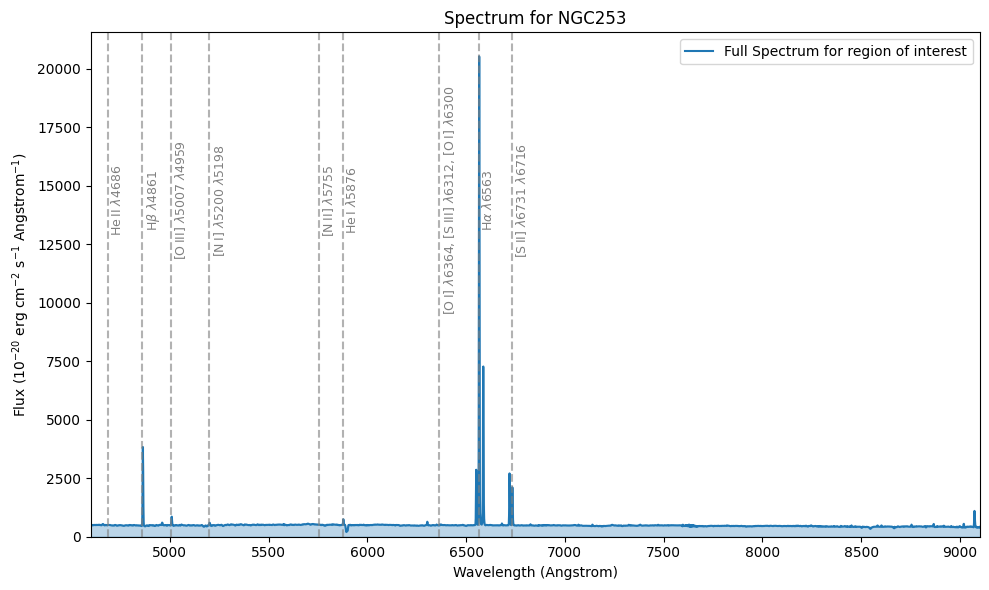

In [12]:
# Define some key emission lines in Angstrom
# Some are very close together and as such we group them... 
lines = {
    r'He II $\lambda$4686': 4686,
    r'H$\beta$ $\lambda$4861': 4861,
    # r'[O III] $\lambda$4959': 4959,
    r'[O III] $\lambda$5007 $\lambda$4959': 5007,
    # r'[N I] $\lambda$5198': 5198,
    r'[N I] $\lambda$5200 $\lambda$5198': 5200,
    r'[N II] $\lambda$5755': 5755,
    r'He I $\lambda$5876': 5876,
    # r'[O I] $\lambda$6300': 6300,
    # r'[S III] $\lambda$6312': 6312,
    r'[O I] $\lambda$6364, [S III] $\lambda$6312, [O I] $\lambda$6300': 6364,
    # r'[N II] $\lambda$6548': 6548,
    r'H$\alpha$ $\lambda$6563': 6563,
    # r'[N II] $\lambda$6584': 6584,
    # r'[S II] $\lambda$6716': 6716,
    r'[S II] $\lambda$6731 $\lambda$6716': 6731,
}

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(data_wave, data_spec, label='Full Spectrum for region of interest')
ax.fill_between(data_wave, 0, data_spec, where=(data_spec > 0), alpha=0.3, color='C0')

# Add vertical lines and labels for key lines
for label, wave in lines.items():
    if ax.get_xlim()[0] < wave < ax.get_xlim()[1]:  # Only show if within plotting range
        ax.axvline(wave, color='gray', linestyle='--', alpha=0.6)
        ax.text(wave + 12, np.nanmax(data_spec) * 0.7, label, rotation=90,
                verticalalignment='center', fontsize=9, color='gray')

ax.set_xlabel('Wavelength (Angstrom)')
ax.set_ylabel(r'Flux (10$^{-20}$ erg cm$^{-2}$ s$^{-1}$ Angstrom$^{-1}$)')
ax.set_title(f'Spectrum for {target}')

ax.set_ylim(0, np.nanmax(data_spec) * 1.05)  # Set y-limits to avoid clipping
ax.set_xlim(4600, 9100)

ax.legend()
fig.tight_layout()
fig.savefig("./figures/muse_ngc253_spectrum_full.png", dpi=300, bbox_inches='tight')

<hr style="border:2px solid #0281c9"> </hr>